In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
import xgboost as xgb
from sklearn.metrics import classification_report, PrecisionRecallDisplay
from scipy.stats import entropy

train_df = pd.read_csv("data/input/train_split.csv")
val_df = pd.read_csv("data/input/val_split.csv")

train_df['comment_text'] = train_df['comment_text'].fillna("missing")
val_df['comment_text'] = val_df['comment_text'].fillna("missing")

In [3]:
print("Building CatBoost Text Pools...")

# We pass a 2D array/DataFrame of strictly the text column
X_train_text = train_df[['comment_text']]
X_val_text = val_df[['comment_text']]

y_train_toxic = train_df['toxicity'].values
y_val_toxic = val_df['toxicity'].values

# The Pool object tells CatBoost exactly which columns contain raw text
train_pool = Pool(
    data=X_train_text, 
    label=y_train_toxic, 
    text_features=['comment_text']
)

val_pool = Pool(
    data=X_val_text, 
    label=y_val_toxic, 
    text_features=['comment_text']
)

Building CatBoost Text Pools...


In [4]:
print("Training CatBoost Gatekeeper...")

pos_weight = len(y_train_toxic[y_train_toxic == 0]) / len(y_train_toxic[y_train_toxic == 1])

# CatBoost has specific hyperparameters for text processing under the hood
cb_gatekeeper = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    scale_pos_weight=pos_weight,
    eval_metric='AUC:hints=skip_train~false', # Track AUC
    early_stopping_rounds=50,
    task_type="GPU", # Switch to "CPU" if running locally without CUDA
    verbose=50
)

cb_gatekeeper.fit(train_pool, eval_set=val_pool)

val_probs_cb = cb_gatekeeper.predict_proba(val_pool)[:, 1]
val_preds_cb = (val_probs_cb > 0.5).astype(int)

Training CatBoost Gatekeeper...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	learn: 0.6376099	test: 0.6307721	best: 0.6307721 (0)	total: 169ms	remaining: 1m 24s
50:	learn: 0.8419468	test: 0.8684983	best: 0.8685919 (48)	total: 1.79s	remaining: 15.8s
100:	learn: 0.8530532	test: 0.8748653	best: 0.8748653 (100)	total: 3.3s	remaining: 13s
150:	learn: 0.8634482	test: 0.8769017	best: 0.8769456 (144)	total: 4.78s	remaining: 11s
200:	learn: 0.8711368	test: 0.8776152	best: 0.8776788 (199)	total: 6.23s	remaining: 9.27s
250:	learn: 0.8781861	test: 0.8781534	best: 0.8781595 (220)	total: 7.77s	remaining: 7.7s
bestTest = 0.8781594634
bestIteration = 220
Shrink model to first 221 iterations.


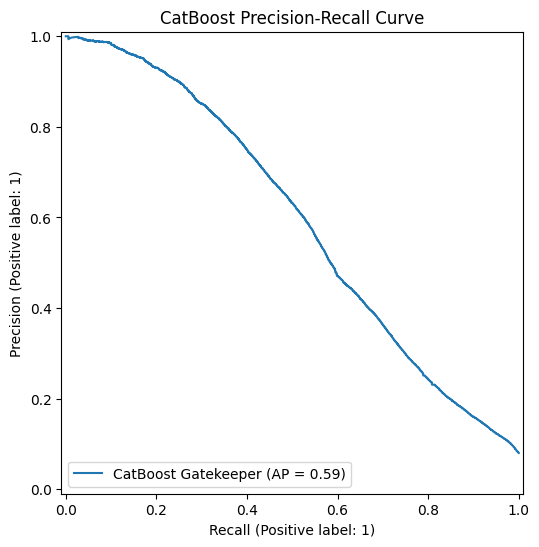


CatBoost Gatekeeper Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92    294358
           1       0.32      0.73      0.45     25565

    accuracy                           0.86    319923
   macro avg       0.65      0.80      0.68    319923
weighted avg       0.92      0.86      0.88    319923



In [5]:
# Note: CatBoost feature importance for a single text column just shows "comment_text" as 100% important.
# To see inside the black box, we rely heavily on the PR Curve.

fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_val_toxic, val_probs_cb, ax=ax, name="CatBoost Gatekeeper")
ax.set_title("CatBoost Precision-Recall Curve")
plt.show()

print("\nCatBoost Gatekeeper Classification Report:")
print(classification_report(y_val_toxic, val_preds_cb))

Loading and preparing Test Data...
Evaluating CatBoost Gatekeeper on Test Data...

CatBoost Gatekeeper Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.95      0.88      0.91   1471786
           1       0.26      0.48      0.34    127826

    accuracy                           0.85   1599612
   macro avg       0.60      0.68      0.62   1599612
weighted avg       0.90      0.85      0.87   1599612

Generating Test Data Confusion Matrix...

Confusion Matrix:
[[1292655  179131]
 [  65923   61903]]


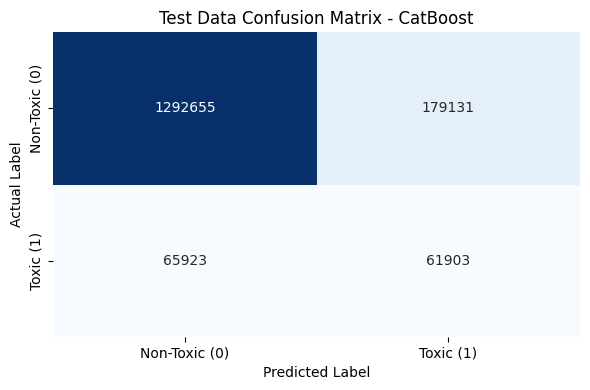

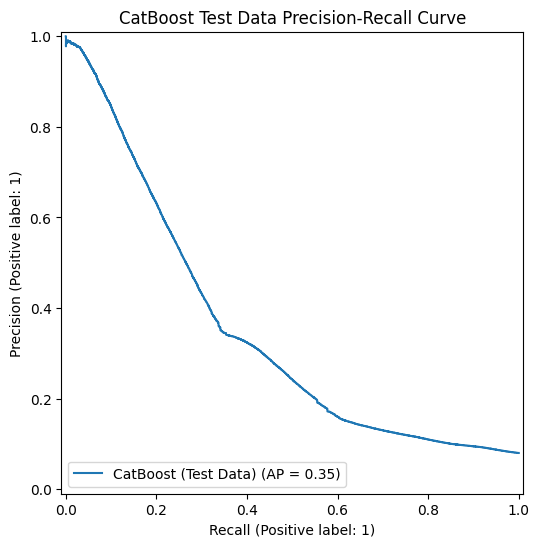

In [7]:
# %%
print("Loading and preparing Test Data...")
# Load the test dataset
test_df = pd.read_csv("data/input/test_split.csv")
test_df['comment_text'] = test_df['comment_text'].fillna("missing")

X_test_text = test_df[['comment_text']]
y_test_toxic = test_df['toxicity'].values

# Create the test Pool, matching the structure of train/val pools
# We must specify text_features again so CatBoost knows how to process it
test_pool = Pool(
    data=X_test_text, 
    label=y_test_toxic, 
    text_features=['comment_text']
)

# %%
print("Evaluating CatBoost Gatekeeper on Test Data...")

# Predict probability of toxicity for the test set
# CatBoost predict_proba returns a 2D array [prob_class_0, prob_class_1], so we slice [:, 1]
test_probs_cb = cb_gatekeeper.predict_proba(test_pool)[:, 1]

# Convert probabilities to binary predictions (using 0.5 threshold)
test_preds_cb = (test_probs_cb > 0.5).astype(int)

# Print the final test metrics
print("\nCatBoost Gatekeeper Classification Report (Test Data):")
print(classification_report(y_test_toxic, test_preds_cb))

# %%
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("Generating Test Data Confusion Matrix...")
# Generate the confusion matrix for visual evaluation
cm_test = confusion_matrix(y_test_toxic, test_preds_cb)

print("\nConfusion Matrix:")
print(cm_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Toxic (0)', 'Toxic (1)'], 
            yticklabels=['Non-Toxic (0)', 'Toxic (1)'])
plt.title('Test Data Confusion Matrix - CatBoost')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# %%
# Optional: Plot the Precision-Recall curve for the test data as well
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test_toxic, test_probs_cb, ax=ax, name="CatBoost (Test Data)")
ax.set_title("CatBoost Test Data Precision-Recall Curve")
plt.show()

Generating Precision, Recall, and F1 curves across thresholds...


C:\Users\priya\AppData\Local\Temp\ipykernel_38696\3051735341.py:47: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\priya\anaconda3\envs\toxicity\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


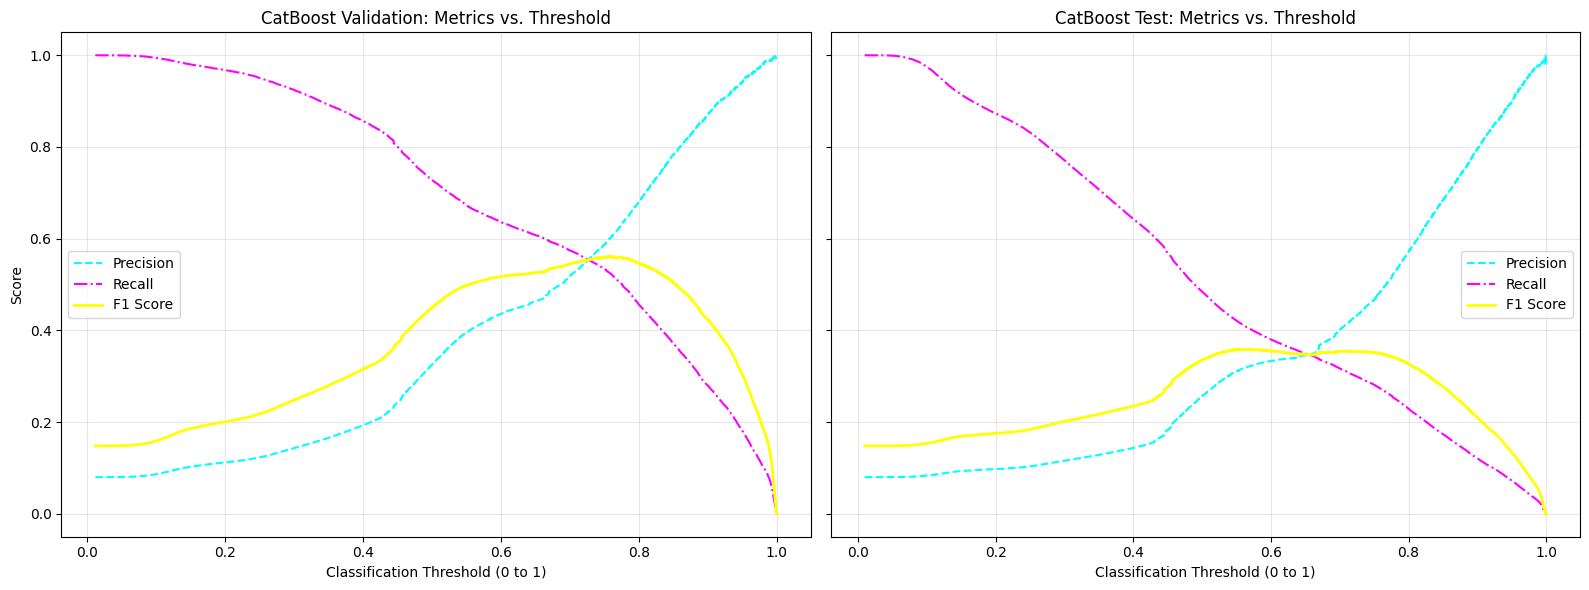

Optimal Threshold for Validation (Max F1): 0.7579 (F1: 0.5605)


In [8]:
# %%
from sklearn.metrics import precision_recall_curve
import numpy as np

print("Generating Precision, Recall, and F1 curves across thresholds...")

# --- Validation Data Metrics ---
# Get precision, recall, and thresholds using CatBoost validation probabilities
precision_val, recall_val, thresholds_val = precision_recall_curve(y_val_toxic, val_probs_cb)

# Calculate F1 score (handling potential division by zero at extreme thresholds)
f1_val = np.divide(2 * precision_val * recall_val, (precision_val + recall_val), 
                   out=np.zeros_like(precision_val), where=(precision_val + recall_val) != 0)

# --- Test Data Metrics ---
# Get precision, recall, and thresholds using CatBoost test probabilities
precision_test, recall_test, thresholds_test = precision_recall_curve(y_test_toxic, test_probs_cb)

f1_test = np.divide(2 * precision_test * recall_test, (precision_test + recall_test), 
                    out=np.zeros_like(precision_test), where=(precision_test + recall_test) != 0)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Note: precision_recall_curve returns one extra value (1 for precision, 0 for recall) 
# at the very end. We use [:-1] to slice them so they match the length of the thresholds array.

# 1. Validation Curves
axes[0].plot(thresholds_val, precision_val[:-1], label='Precision', color='cyan', linestyle='--')
axes[0].plot(thresholds_val, recall_val[:-1], label='Recall', color='magenta', linestyle='-.')
axes[0].plot(thresholds_val, f1_val[:-1], label='F1 Score', color='yellow', linewidth=2)
axes[0].set_title('CatBoost Validation: Metrics vs. Threshold')
axes[0].set_xlabel('Classification Threshold (0 to 1)')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Test Curves
axes[1].plot(thresholds_test, precision_test[:-1], label='Precision', color='cyan', linestyle='--')
axes[1].plot(thresholds_test, recall_test[:-1], label='Recall', color='magenta', linestyle='-.')
axes[1].plot(thresholds_test, f1_test[:-1], label='F1 Score', color='yellow', linewidth=2)
axes[1].set_title('CatBoost Test: Metrics vs. Threshold')
axes[1].set_xlabel('Classification Threshold (0 to 1)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find the optimal threshold that maximizes the F1 score on Validation data
best_idx = np.argmax(f1_val)
# Ensure we don't grab the index if it falls exactly on the final appended value
if best_idx == len(thresholds_val):
    best_idx -= 1
    
best_threshold = thresholds_val[best_idx]
print(f"Optimal Threshold for Validation (Max F1): {best_threshold:.4f} (F1: {f1_val[best_idx]:.4f})")